## Trying to perform AZURE2 fit using Brick

Using a working example such as 12C(p,p)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional, Literal
import pandas as pd

from brick.azr import AZR
from brick.output import Output

Build `ChiSquareMinimizer`class and `Parameter` class

In [2]:
from dataclasses import dataclass
from typing import Dict, List, Optional
import numpy as np
import pandas as pd
from scipy.optimize import minimize


@dataclass
class Parameter:
    """An AZURE2 parameter with bounds"""

    name: str
    value: float
    lower: Optional[float] = None
    upper: Optional[float] = None

    def set_auto_bounds(self) -> None:
        """Automatically sets bounds depending on the parameter type"""
        lowf = 0.5
        upf = 1.5
        self.lower = self.value * lowf
        self.upper = self.value * upf

    def __str__(self):
        return f"{self.name} = {self.value} in [{self.lower}, {self.upper}]"


class Chi2Minimizer:
    def __init__(self, azr: AZR, pars: List[Parameter], n_workers: int = 1) -> None:
        self.azr = azr
        self.pars = pars
        self.n_workers = n_workers
        self.result = None

        # Disable AZURE2 MT
        import os
        os.environ["OMP_NUM_THREADS"] = "1"

    def residuals(self, pars):
        """Compute residuals (y - mu) / uy"""
        pred = self.azr.predict(pars)[0]
        mu = pred.xs_com_fit  # type: ignore
        y = pred.xs_com_data  # type: ignore
        uy = pred.xs_err_com_data  # type: ignore
        return (y - mu) / uy

    def chi_square(self, pars):
        """Objective: chi-square = sum(residuals^2)"""
        res = self.residuals(pars)
        return np.sum(res**2)

    def fit(self, maxiter: int = 2000) -> None:
        """Chi-square minimization using scipy.optimize.minimize"""
        bounds = [(p.lower, p.upper) for p in self.pars]
        x0 = np.array([p.value for p in self.pars])

        self.result = minimize(
            self.chi_square,
            x0,
            method="L-BFGS-B",
            bounds=bounds,
            options={"maxiter": maxiter, "ftol": 1e-10},
        )

        if not self.result.success:
            print(f"Warning: minimization did not fully converge: {self.result.message}")
        print(f"Minimization complete. Chi^2 = {self.result.fun:.6f}")

    def summary(self) -> pd.DataFrame:
        """Return fitted parameters as DataFrame."""
        if self.result is None:
            raise ValueError("Run .fit() first")
        return pd.DataFrame(
            {
                "Parameter": [p.name for p in self.pars],
                "Initial": self.azr.config.get_input_values(),
                "Value": self.result.x,
                "Lower Bound": [p.lower for p in self.pars],
                "Upper Bound": [p.upper for p in self.pars],
            }
        )

    def get_params(self) -> Dict[str, float]:
        """Get fitted parameters as dict"""
        if self.result is None:
            raise ValueError("Run .fit() first")
        return {p.name: val for p, val in zip(self.pars, self.result.x)}

    def get_best_fit(self) -> Output | None:
        """Get best fit prediction"""
        if self.result is None:
            return None
        return self.azr.predict(self.result.x)[0]  # type: ignore

    @property
    def chi_square_value(self):
        """Get chi-square of best fit"""
        if self.result is None:
            raise ValueError("Run .fit() first")
        return self.chi_square(self.result.x)

In [5]:
azr = AZR("./12C+p.azr")

# Get parameters
nd = azr.config.nd
pars: List[Parameter] = []
for i in range(nd):
    name = azr.config.labels[i]
    init_value = azr.config.get_input_values()[i]
    if i == 1:
        init_value = 2.2
    par = Parameter(name=name, value=init_value)
    par.set_auto_bounds()
    pars.append(par)
    print(par)


minimizer = Chi2Minimizer(azr, pars, n_workers=1)
minimizer.fit()
minimizer.summary()

$C_{1,1}^{(-0.5)}$ = 2.5 in [1.25, 3.75]
$E_{1,1}^{(+0.5)}$ = 2.2 in [1.1, 3.3000000000000003]
$\Gamma_{1,1}^{(+0.5)}$ = 31700.0 in [15850.0, 47550.0]
$E_{1,1}^{(-1.5)}$ = 3.502 in [1.751, 5.253]
$\Gamma_{1,1}^{(-1.5)}$ = 62000.0 in [31000.0, 93000.0]
$E_{1,1}^{(+2.5)}$ = 3.547 in [1.7735, 5.3205]
$\Gamma_{1,1}^{(+2.5)}$ = 47000.0 in [23500.0, 70500.0]
$n_{3}$ = 1.0 in [0.5, 1.5]
Minimization complete. Chi^2 = 88829.517199


,Parameter,Initial,Value,Lower Bound,Upper Bound
0,"$C_{1,1}^{(-0.5)}$",2.50000,2.500000,1.2500,3.7500
1,"$E_{1,1}^{(+0.5)}$",2.36490,2.190830,1.1000,3.3000
2,"$\Gamma_{1,1}^{(+0.5)}$",31700.00000,31700.000000,15850.0000,47550.0000
3,"$E_{1,1}^{(-1.5)}$",3.50200,3.499078,1.7510,5.2530
4,"$\Gamma_{1,1}^{(-1.5)}$",62000.00000,62000.000000,31000.0000,93000.0000
5,"$E_{1,1}^{(+2.5)}$",3.54700,3.546178,1.7735,5.3205
6,"$\Gamma_{1,1}^{(+2.5)}$",47000.00000,47000.000000,23500.0000,70500.0000
7,$n_{3}$,0.99716,0.997160,0.5000,1.5000


  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 88829.51719878853
        x: [ 2.500e+00  2.191e+00  3.170e+04  3.499e+00  6.200e+04
             3.546e+00  4.700e+04  9.972e-01]
      nit: 19
      jac: [ 0.000e+00  3.678e+05  0.000e+00  3.381e+04  0.000e+00
            -3.003e+02  0.000e+00  1.914e+05]
     nfev: 720
     njev: 80
 hess_inv: <8x8 LbfgsInvHessProduct with dtype=float64>


Text(0, 0.5, '$\\sigma$ [mb]')

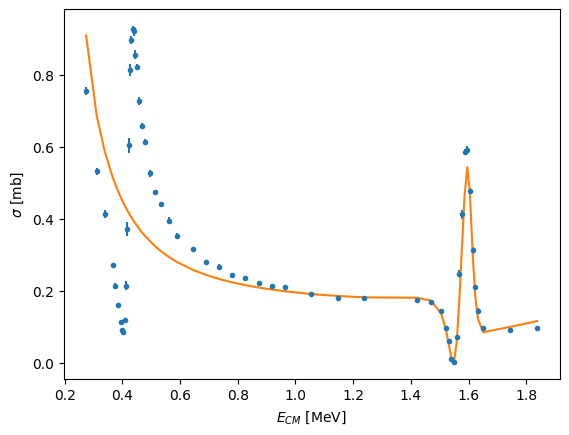

In [6]:
print(minimizer.result)
fig, ax = plt.subplots()

# Get best fit
best = minimizer.get_best_fit()
assert best is not None, "Results is None"
# Get data
x = best.e_com
y = best.xs_com_data
uy = best.xs_err_com_data
fit = best.xs_com_fit
ax.errorbar(x, y, yerr=uy, ls="none", marker="o", ms=3)
ax.plot(x, fit)

# Axis settings
ax.set_xlabel(r"$E_{CM}$ [MeV]")
ax.set_ylabel(r"$\sigma$ [mb]")

